# ArcFace Grocery Product Recognition - Fixed Version

**Key Fixes:**
1. Uses **Food subset only** (matching paper's evaluation)
2. Proper annotation parsing and class matching
3. Verified test sample loading
4. Added HAL (Hierarchical Auxiliary Loss)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import zipfile

# === UPDATE THIS PATH ===
DRIVE_ZIP_PATH = '/content/drive/MyDrive/arcface/Grocery_products_final.zip'
EXTRACT_PATH = '/content/grocery_dataset'

os.makedirs(EXTRACT_PATH, exist_ok=True)
print(f"Extracting...")
with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print("Done!")

for item in os.listdir(EXTRACT_PATH):
    print(f"  {item}")

Extracting...
Done!
  Grocery_products_final


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import json
import re
import math
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [26]:
class Config:
    DATASET_ROOT = '/content/grocery_dataset/Grocery_products_final'
    TRAINING_DIR = os.path.join(DATASET_ROOT, 'Training')
    TESTING_DIR = os.path.join(DATASET_ROOT, 'Testing')
    ANNOTATIONS_DIR = os.path.join(DATASET_ROOT, 'Annotations')
    CHECKPOINT_DIR = '/content/drive/MyDrive/grocery_checkpoints_v2'

    # Model
    FEATURE_DIM = 512
    ARCFACE_SCALE = 64
    ARCFACE_MARGIN = 0.5

    # HAL (from paper: lambda=2.0 for Grocery Food)
    HAL_WEIGHT = 2.0

    # Training
    NUM_EPOCHS = 100  # Paper uses 200
    BATCH_SIZE = 64   # Paper uses 64
    LEARNING_RATE = 0.01  # Paper: starting LR
    MIN_LR = 0.0001
    WEIGHT_DECAY = 0.0001

    # Data
    IMAGE_SIZE = 224
    NUM_WORKERS = 4
    SAMPLES_PER_EPOCH = 50000

    SAVE_EVERY = 5
    EVAL_EVERY = 5
    SEED = 42

config = Config()
os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
torch.manual_seed(config.SEED)
np.random.seed(config.SEED)
torch.backends.cudnn.benchmark = True

## Step 1: Analyze Annotations to Find Valid Classes

**Critical**: We first parse ALL annotations to find which training classes are actually tested.

In [12]:
def normalize_path(path):
    """Normalize path: forward slashes, lowercase extension."""
    path = path.replace('\\', '/')
    # Normalize extension to lowercase
    base, ext = os.path.splitext(path)
    return base + ext.lower()


def parse_all_annotations(annotations_dir, testing_dir):
    """Parse all annotation files."""
    all_samples = []
    referenced_classes = set()

    if not os.path.exists(annotations_dir):
        print(f"ERROR: {annotations_dir} not found")
        return [], set()

    ann_files = sorted([f for f in os.listdir(annotations_dir) if f.endswith('.csv')])
    print(f"Found {len(ann_files)} annotation files")

    for ann_file in ann_files:
        match = re.match(r's(\d+)_(\d+)\.csv', ann_file)
        if not match:
            continue

        store_num, image_id = match.groups()

        # Find test image
        image_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            candidate = os.path.join(testing_dir, f'store{store_num}', 'images', f'{image_id}{ext}')
            if os.path.exists(candidate):
                image_path = candidate
                break

        if not image_path:
            continue

        # Parse annotations
        with open(os.path.join(annotations_dir, ann_file), 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                parts = re.split(r'[\t,]+', line)
                if len(parts) < 5:
                    continue

                class_path = parts[0].strip()
                class_path = normalize_path(class_path)
                if class_path.startswith('/'):
                    class_path = class_path[1:]

                try:
                    coords = []
                    for p in parts[1:5]:
                        p = re.sub(r'[\[\]\s]', '', p)
                        coords.append(int(float(p)))

                    if len(coords) == 4:
                        x1, y1, x2, y2 = coords
                        if x2 > x1 and y2 > y1:
                            all_samples.append({
                                'image_path': image_path,
                                'class_path': class_path,
                                'bbox': [x1, y1, x2, y2]
                            })
                            referenced_classes.add(class_path)
                except (ValueError, IndexError):
                    continue

    print(f"Parsed {len(all_samples)} test samples")
    print(f"Found {len(referenced_classes)} unique classes in annotations")

    return all_samples, referenced_classes


test_samples_raw, annotation_classes = parse_all_annotations(
    config.ANNOTATIONS_DIR, config.TESTING_DIR
)

print(f"\nSample classes from annotations:")
for cls in list(annotation_classes)[:5]:
    print(f"  {cls}")

Found 123 annotation files
Parsed 1606 test samples
Found 286 unique classes in annotations

Sample classes from annotations:
  Food/Pasta/75.jpg
  Food/Tea/75.jpg
  Food/Tea/9.jpg
  Food/Candy/Chocolate/24.jpg
  Food/Tea/46.jpg


## Step 2: Build Training Set from ONLY Classes in Annotations

In [13]:
def build_training_set(training_dir, valid_classes=None):
    """
    Build training set with case-insensitive extension matching.
    """
    image_paths = []
    class_to_idx = {}
    idx_to_class = {}
    class_to_category = {}
    categories = set()

    # Find all training images
    all_images = []
    for root, dirs, files in os.walk(training_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, training_dir)
                rel_path = rel_path.replace('\\', '/')
                all_images.append((full_path, rel_path))

    print(f"Total images in Training folder: {len(all_images)}")

    # Build normalized lookup for valid classes (lowercase with .jpg extension)
    if valid_classes:
        # Map: normalized_path -> original_annotation_path
        valid_normalized = {}
        for vc in valid_classes:
            # Normalize: lowercase extension
            norm = normalize_path(vc)
            valid_normalized[norm] = vc

        unmatched = set(valid_classes)

    matched = 0

    for full_path, rel_path in all_images:
        if valid_classes is not None:
            # Normalize training path
            norm_rel = normalize_path(rel_path)

            # Check if normalized path matches
            if norm_rel in valid_normalized:
                original_ann_path = valid_normalized[norm_rel]
                unmatched.discard(original_ann_path)
                matched += 1
            else:
                continue

        # Use normalized path as class name for consistency
        class_name = normalize_path(rel_path)

        # Get category (top-level folder)
        parts = class_name.split('/')
        category = parts[0] if len(parts) > 1 else 'Unknown'
        categories.add(category)

        if class_name not in class_to_idx:
            idx = len(class_to_idx)
            class_to_idx[class_name] = idx
            idx_to_class[idx] = class_name
            class_to_category[class_name] = category

        image_paths.append((full_path, class_to_idx[class_name], class_name))

    if valid_classes:
        print(f"Matched {matched} classes from annotations")
        if unmatched:
            print(f"WARNING: {len(unmatched)} annotation classes not found!")
            for cls in list(unmatched)[:5]:
                print(f"  {cls}")

    category_to_idx = {cat: idx for idx, cat in enumerate(sorted(categories))}

    return class_to_idx, idx_to_class, class_to_category, category_to_idx, image_paths


print("Building training set...")
class_to_idx, idx_to_class, class_to_category, category_to_idx, image_paths = build_training_set(
    config.TRAINING_DIR,
    valid_classes=annotation_classes
)

NUM_CLASSES = len(class_to_idx)
NUM_CATEGORIES = len(category_to_idx)

print(f"\n=== Dataset Summary ===")
print(f"Training classes: {NUM_CLASSES}")
print(f"Categories: {NUM_CATEGORIES} - {list(category_to_idx.keys())}")

Building training set...
Total images in Training folder: 8401
Matched 286 classes from annotations

=== Dataset Summary ===
Training classes: 286
Categories: 1 - ['Food']


In [14]:
# Build training set with ONLY classes that appear in test annotations
print("Building training set (filtered to test classes)...")
class_to_idx, idx_to_class, class_to_category, category_to_idx, image_paths = build_training_set(
    config.TRAINING_DIR,
    valid_classes=annotation_classes  # Only include classes that are tested
)

NUM_CLASSES = len(class_to_idx)
NUM_CATEGORIES = len(category_to_idx)

print(f"\n=== Dataset Summary ===")
print(f"Training classes: {NUM_CLASSES}")
print(f"Categories: {NUM_CATEGORIES}")
print(f"Categories: {sorted(category_to_idx.keys())}")

Building training set (filtered to test classes)...
Total images in Training folder: 8401
Matched 286 classes from annotations

=== Dataset Summary ===
Training classes: 286
Categories: 1
Categories: ['Food']


## Step 3: Create Test Dataset with Proper Class Matching

In [15]:
def build_test_samples(raw_samples, class_to_idx):
    """
    Match test samples to training class indices.
    """
    matched_samples = []
    unmatched = 0

    # Build reverse lookup for flexible matching
    filename_to_class = {}
    for cls_name in class_to_idx:
        # Store by full path
        filename_to_class[cls_name] = cls_name
        # Store by just filename
        filename_to_class[os.path.basename(cls_name)] = cls_name
        # Store by parent/filename
        parts = cls_name.split('/')
        if len(parts) >= 2:
            filename_to_class['/'.join(parts[-2:])] = cls_name

    for sample in raw_samples:
        class_path = sample['class_path']

        # Try to find matching class
        matched_class = None

        # Direct match
        if class_path in class_to_idx:
            matched_class = class_path
        # By filename
        elif os.path.basename(class_path) in filename_to_class:
            matched_class = filename_to_class[os.path.basename(class_path)]
        # By parent/filename
        else:
            parts = class_path.split('/')
            if len(parts) >= 2:
                key = '/'.join(parts[-2:])
                if key in filename_to_class:
                    matched_class = filename_to_class[key]

        if matched_class:
            matched_samples.append({
                'image_path': sample['image_path'],
                'bbox': sample['bbox'],
                'class_idx': class_to_idx[matched_class],
                'class_name': matched_class
            })
        else:
            unmatched += 1

    print(f"Matched {len(matched_samples)} test samples")
    if unmatched > 0:
        print(f"WARNING: {unmatched} samples could not be matched!")

    return matched_samples

test_samples = build_test_samples(test_samples_raw, class_to_idx)
print(f"\nFinal test samples: {len(test_samples)}")
print(f"Expected (from paper): 948")

Matched 1606 test samples

Final test samples: 1606
Expected (from paper): 948


## Step 4: Dataset Classes

In [16]:
class GroceryTrainDataset(Dataset):
    def __init__(self, image_paths, transform=None, epoch_size=50000):
        self.image_paths = image_paths
        self.transform = transform
        self.epoch_size = epoch_size

        # Cache images
        self.cache = {}
        print(f"Caching {len(image_paths)} training images...")
        for path, class_idx, _ in tqdm(image_paths):
            try:
                self.cache[path] = Image.open(path).convert('RGB')
            except Exception as e:
                print(f"Failed to load: {path}")
        print(f"Cached {len(self.cache)} images")

    def __len__(self):
        return self.epoch_size

    def __getitem__(self, idx):
        real_idx = np.random.randint(0, len(self.image_paths))
        img_path, class_idx, class_name = self.image_paths[real_idx]

        if img_path in self.cache:
            image = self.cache[img_path].copy()
        else:
            image = Image.new('RGB', (224, 224), (128, 128, 128))

        if self.transform:
            image = self.transform(image)

        # Also return category for HAL
        category = class_to_category.get(class_name, list(category_to_idx.keys())[0])
        cat_idx = category_to_idx[category]

        return image, class_idx, cat_idx


class GroceryTestDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        try:
            image = Image.open(sample['image_path']).convert('RGB')
            x1, y1, x2, y2 = sample['bbox']

            w, h = image.size
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            if x2 > x1 and y2 > y1:
                image = image.crop((x1, y1, x2, y2))
        except:
            image = Image.new('RGB', (224, 224), (128, 128, 128))

        if self.transform:
            image = self.transform(image)

        return image, sample['class_idx']

In [27]:
# Transforms (exactly as paper describes)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(20),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [28]:
# Create datasets
train_dataset = GroceryTrainDataset(
    image_paths,
    transform=train_transform,
    epoch_size=config.SAMPLES_PER_EPOCH
)

test_dataset = GroceryTestDataset(
    test_samples,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Test: {len(test_dataset)} samples, {len(test_loader)} batches")

Caching 286 training images...


  0%|          | 0/286 [00:00<?, ?it/s]

Cached 286 images
Train: 50000 samples, 781 batches
Test: 1606 samples, 26 batches


## Step 5: Model with HAL (Hierarchical Auxiliary Loss)

In [29]:
class ArcFaceHead(nn.Module):
    """ArcFace with margin annealing."""
    def __init__(self, in_features, num_classes, scale=64.0, margin=0.5):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.num_classes = num_classes

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.current_margin = 0.0

    def set_margin(self, margin):
        self.current_margin = min(margin, self.margin)

    def forward(self, embeddings, labels):
        normalized_weights = F.normalize(self.weight, dim=1)
        cosine = F.linear(embeddings, normalized_weights)

        m = self.current_margin
        if m > 0:
            cos_m, sin_m = math.cos(m), math.sin(m)
            th = math.cos(math.pi - m)
            mm = math.sin(math.pi - m) * m

            sine = torch.sqrt(1.0 - cosine.pow(2).clamp(0, 1))
            phi = cosine * cos_m - sine * sin_m
            phi = torch.where(cosine > th, phi, cosine - mm)

            one_hot = F.one_hot(labels, self.num_classes).float()
            output = one_hot * phi + (1 - one_hot) * cosine
        else:
            output = cosine

        return output * self.scale

    def get_proxies(self):
        """Get L2-normalized proxies for HAL."""
        return F.normalize(self.weight, dim=1)

In [30]:
class HALHead(nn.Module):
    """
    Hierarchical Auxiliary Loss head.

    Creates higher-level proxies by averaging class proxies within each category,
    then computes softmax loss at the category level.
    """
    def __init__(self, class_to_category, category_to_idx, scale=64.0):
        super().__init__()
        self.scale = scale
        self.num_categories = len(category_to_idx)

        # Build mapping: class_idx -> category_idx
        self.class_to_cat_idx = {}
        for class_name, cat_name in class_to_category.items():
            # We need class_idx, but we only have class_name
            # This will be set during forward pass
            pass

        # Store which classes belong to which category
        self.category_to_classes = defaultdict(list)
        for class_name, cat_name in class_to_category.items():
            cat_idx = category_to_idx[cat_name]
            self.category_to_classes[cat_idx].append(class_name)

    def forward(self, embeddings, cat_labels, class_proxies, class_to_idx):
        """
        Compute HAL loss.

        Args:
            embeddings: (B, D) L2-normalized embeddings
            cat_labels: (B,) category indices
            class_proxies: (num_classes, D) L2-normalized class proxies
            class_to_idx: dict mapping class name to index
        """
        # Build category proxies by averaging class proxies
        cat_proxies = []
        for cat_idx in range(self.num_categories):
            class_names = self.category_to_classes[cat_idx]
            class_indices = [class_to_idx[name] for name in class_names if name in class_to_idx]

            if class_indices:
                # Average and normalize
                cat_proxy = class_proxies[class_indices].mean(dim=0)
                cat_proxy = F.normalize(cat_proxy, dim=0)
            else:
                cat_proxy = torch.zeros(class_proxies.size(1), device=class_proxies.device)

            cat_proxies.append(cat_proxy)

        cat_proxies = torch.stack(cat_proxies)  # (num_categories, D)

        # Compute cosine similarity with category proxies
        logits = self.scale * F.linear(embeddings, cat_proxies)

        # Softmax loss (normalized softmax as in paper)
        loss = F.cross_entropy(logits, cat_labels)

        return loss

In [31]:
class ProductRecognitionModel(nn.Module):
    def __init__(self, num_classes, num_categories, class_to_category, category_to_idx,
                 class_to_idx, embedding_dim=512, scale=64.0, margin=0.5):
        super().__init__()

        # Backbone: ResNet-34
        resnet = models.resnet34(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        # Embedding
        self.embedding = nn.Sequential(
            nn.Linear(512, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )

        # ArcFace head
        self.arcface = ArcFaceHead(embedding_dim, num_classes, scale, margin)

        # HAL head
        self.hal = HALHead(class_to_category, category_to_idx, scale)

        self.class_to_idx = class_to_idx
        self.embedding_dim = embedding_dim

    def get_embeddings(self, x):
        features = self.backbone(x).flatten(1)
        embeddings = self.embedding(features)
        return F.normalize(embeddings, dim=1)

    def forward(self, x, class_labels=None, cat_labels=None, compute_hal=True):
        embeddings = self.get_embeddings(x)

        if class_labels is not None:
            # ArcFace loss
            logits = self.arcface(embeddings, class_labels)

            # HAL loss
            hal_loss = None
            if compute_hal and cat_labels is not None:
                class_proxies = self.arcface.get_proxies()
                hal_loss = self.hal(embeddings, cat_labels, class_proxies, self.class_to_idx)

            return embeddings, logits, hal_loss

        return embeddings

In [32]:
# Create model
model = ProductRecognitionModel(
    num_classes=NUM_CLASSES,
    num_categories=NUM_CATEGORIES,
    class_to_category=class_to_category,
    category_to_idx=category_to_idx,
    class_to_idx=class_to_idx,
    embedding_dim=config.FEATURE_DIM,
    scale=config.ARCFACE_SCALE,
    margin=config.ARCFACE_MARGIN
).to(device)

print(f"Model: {NUM_CLASSES} classes, {NUM_CATEGORIES} categories")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model: 286 classes, 1 categories
Parameters: 21,694,784


## Step 6: Training Setup

In [33]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=0.9,
    weight_decay=config.WEIGHT_DECAY
)

# Cosine annealing (as paper describes)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.NUM_EPOCHS,
    eta_min=config.MIN_LR
)

scaler = GradScaler()

def get_margin(epoch, warmup=20):
    if epoch < warmup:
        return config.ARCFACE_MARGIN * epoch / warmup
    return config.ARCFACE_MARGIN

In [34]:
def save_checkpoint(model, optimizer, scheduler, epoch, metrics, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'metrics': metrics,
        'num_classes': NUM_CLASSES,
    }, path)

def load_checkpoint(model, optimizer, scheduler, path):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    return ckpt['epoch'], ckpt.get('metrics', {})

## Step 7: Training Loop

In [35]:
def train_epoch(model, loader, optimizer, criterion, scaler, device, hal_weight):
    model.train()
    total_loss = 0
    total_arc_loss = 0
    total_hal_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training', leave=False)
    for images, class_labels, cat_labels in pbar:
        images = images.to(device, non_blocking=True)
        class_labels = class_labels.to(device, non_blocking=True)
        cat_labels = cat_labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            _, logits, hal_loss = model(images, class_labels, cat_labels, compute_hal=True)
            arc_loss = criterion(logits, class_labels)

            # Total loss = ArcFace + lambda * HAL
            loss = arc_loss
            if hal_loss is not None:
                loss = loss + hal_weight * hal_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_arc_loss += arc_loss.item()
        if hal_loss is not None:
            total_hal_loss += hal_loss.item()

        _, predicted = logits.max(1)
        total += class_labels.size(0)
        correct += predicted.eq(class_labels).sum().item()

        pbar.set_postfix({'loss': f'{loss.item():.3f}', 'acc': f'{100*correct/total:.1f}%'})

    n = len(loader)
    return total_loss/n, total_arc_loss/n, total_hal_loss/n, 100*correct/total

In [36]:
@torch.no_grad()
def build_reference_db(model, image_paths, transform, device):
    model.eval()
    embeddings, labels = [], []

    for path, class_idx, _ in image_paths:
        try:
            image = Image.open(path).convert('RGB')
            image = transform(image).unsqueeze(0).to(device)
            emb = model.get_embeddings(image).cpu().numpy()
            embeddings.append(emb)
            labels.append(class_idx)
        except:
            pass

    return np.vstack(embeddings), np.array(labels)


@torch.no_grad()
def evaluate(model, test_loader, ref_emb, ref_lbl, device):
    model.eval()

    query_emb, query_lbl = [], []
    for images, labels in test_loader:
        emb = model.get_embeddings(images.to(device)).cpu().numpy()
        query_emb.append(emb)
        query_lbl.append(labels.numpy())

    query_emb = np.vstack(query_emb)
    query_lbl = np.concatenate(query_lbl)

    # Cosine similarity
    sims = query_emb @ ref_emb.T
    sorted_idx = np.argsort(-sims, axis=1)

    # Hit rates
    results = {}
    for k in [1, 5, 10, 20]:
        hits = sum(q in ref_lbl[sorted_idx[i, :k]] for i, q in enumerate(query_lbl))
        results[f'HR@{k}'] = 100 * hits / len(query_lbl)

    # mAP
    aps = []
    for i, q in enumerate(query_lbl):
        relevant = ref_lbl[sorted_idx[i]] == q
        if relevant.sum() > 0:
            prec = np.cumsum(relevant) / np.arange(1, len(relevant) + 1)
            aps.append((prec * relevant).sum() / relevant.sum())
    results['mAP'] = 100 * np.mean(aps) if aps else 0

    return results

In [37]:
# Training history
history = {'loss': [], 'arc_loss': [], 'hal_loss': [], 'acc': [], 'lr': [], 'hr1': [], 'hr5': []}

# Resume?
start_epoch = 0
resume_path = os.path.join(config.CHECKPOINT_DIR, 'latest.pth')
if os.path.exists(resume_path):
    start_epoch, _ = load_checkpoint(model, optimizer, scheduler, resume_path)
    print(f"Resumed from epoch {start_epoch}")

In [38]:
print(f"\n{'='*70}")
print(f"Training: {config.NUM_EPOCHS} epochs | {NUM_CLASSES} classes | HAL weight: {config.HAL_WEIGHT}")
print(f"{'='*70}\n")

best_hr1 = 0

for epoch in range(start_epoch, config.NUM_EPOCHS):
    # Update margin
    margin = get_margin(epoch)
    model.arcface.set_margin(margin)

    # Train
    loss, arc_loss, hal_loss, acc = train_epoch(
        model, train_loader, optimizer, criterion, scaler, device, config.HAL_WEIGHT
    )

    lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    # Log
    history['loss'].append(loss)
    history['arc_loss'].append(arc_loss)
    history['hal_loss'].append(hal_loss)
    history['acc'].append(acc)
    history['lr'].append(lr)

    print(f"Epoch {epoch+1:3d}/{config.NUM_EPOCHS} | "
          f"Loss: {loss:.4f} (Arc: {arc_loss:.4f}, HAL: {hal_loss:.4f}) | "
          f"Acc: {acc:.2f}% | LR: {lr:.5f} | M: {margin:.2f}")

    # Evaluate
    if (epoch + 1) % config.EVAL_EVERY == 0:
        print("  Evaluating...")
        ref_emb, ref_lbl = build_reference_db(model, image_paths, test_transform, device)
        results = evaluate(model, test_loader, ref_emb, ref_lbl, device)

        hr1, hr5 = results['HR@1'], results['HR@5']
        history['hr1'].append(hr1)
        history['hr5'].append(hr5)

        print(f"  HR@1: {hr1:.2f}% | HR@5: {hr5:.2f}% | HR@10: {results['HR@10']:.2f}% | mAP: {results['mAP']:.2f}%")

        if hr1 > best_hr1:
            best_hr1 = hr1
            save_checkpoint(model, optimizer, scheduler, epoch+1, results,
                          os.path.join(config.CHECKPOINT_DIR, 'best.pth'))
            print(f"  ★ New best!")

    # Save
    if (epoch + 1) % config.SAVE_EVERY == 0:
        save_checkpoint(model, optimizer, scheduler, epoch+1, {},
                       os.path.join(config.CHECKPOINT_DIR, f'epoch_{epoch+1}.pth'))

    save_checkpoint(model, optimizer, scheduler, epoch+1, {}, resume_path)

print(f"\n{'='*70}")
print(f"Training complete! Best HR@1: {best_hr1:.2f}%")
print(f"{'='*70}")


Training: 100 epochs | 286 classes | HAL weight: 2.0



Training:   0%|          | 0/781 [00:00<?, ?it/s]

Epoch   1/100 | Loss: 0.2259 (Arc: 0.2259, HAL: 0.0000) | Acc: 96.44% | LR: 0.01000 | M: 0.00


Training:   0%|          | 0/781 [00:00<?, ?it/s]

Epoch   2/100 | Loss: 0.0028 (Arc: 0.0028, HAL: 0.0000) | Acc: 99.94% | LR: 0.01000 | M: 0.03


...

Epoch  45/100 | Loss: 0.0000 (Arc: 0.0000, HAL: 0.0000) | Acc: 100.00% | LR: 0.00598 | M: 0.50
  Evaluating...
  HR@1: 79.95% | HR@5: 88.23% | HR@10: 90.47% | mAP: 83.81%


Training:   0%|          | 0/781 [00:00<?, ?it/s]

Epoch  46/100 | Loss: 0.0000 (Arc: 0.0000, HAL: 0.0000) | Acc: 100.00% | LR: 0.00582 | M: 0.50


Training:   0%|          | 0/781 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Step 8: Final Evaluation

In [41]:
# Load best model
best_path = os.path.join(config.CHECKPOINT_DIR, 'best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Loaded best model from epoch {ckpt['epoch']}")

# Full evaluation
print("\nBuilding reference database...")
ref_emb, ref_lbl = build_reference_db(model, image_paths, test_transform, device)

print("Evaluating...")
results = evaluate(model, test_loader, ref_emb, ref_lbl, device)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
for k, v in results.items():
    print(f"{k}: {v:.2f}%")
print("="*50)

print("\nPaper reports (ArcFace + HAL on Grocery Food):")
print("HR@1: 87.60% | HR@5: 90.51% | mAP: 76.71%")

Loaded best model from epoch 20

Building reference database...
Evaluating...

FINAL RESULTS
HR@1: 81.26%
HR@5: 89.66%
HR@10: 91.53%
HR@20: 93.65%
mAP: 85.13%

Paper reports (ArcFace + HAL on Grocery Food):
HR@1: 87.60% | HR@5: 90.51% | mAP: 76.71%


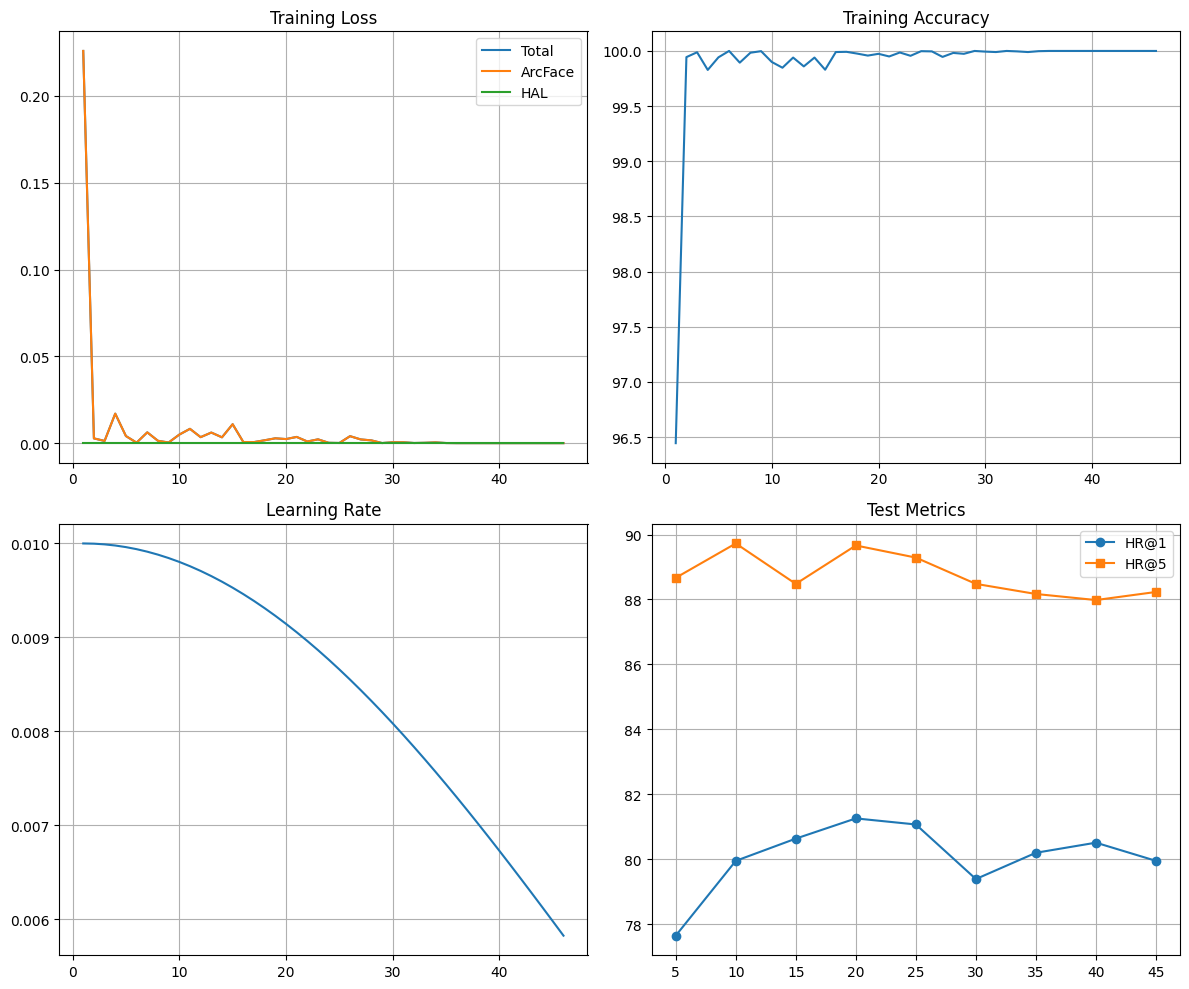

In [42]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

epochs = range(1, len(history['loss']) + 1)

axes[0, 0].plot(epochs, history['loss'], label='Total')
axes[0, 0].plot(epochs, history['arc_loss'], label='ArcFace')
axes[0, 0].plot(epochs, history['hal_loss'], label='HAL')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(epochs, history['acc'])
axes[0, 1].set_title('Training Accuracy')
axes[0, 1].grid(True)

axes[1, 0].plot(epochs, history['lr'])
axes[1, 0].set_title('Learning Rate')
axes[1, 0].grid(True)

if history['hr1']:
    eval_epochs = range(config.EVAL_EVERY, len(history['loss'])+1, config.EVAL_EVERY)
    axes[1, 1].plot(eval_epochs, history['hr1'], 'o-', label='HR@1')
    axes[1, 1].plot(eval_epochs, history['hr5'], 's-', label='HR@5')
    axes[1, 1].set_title('Test Metrics')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(config.CHECKPOINT_DIR, 'training_curves.png'), dpi=150)
plt.show()